# 이미지 생성 AI

In [ ]:
# from diffusers import StableDiffusionPipeline
# import torch
!pip install scheduling_tcd


ERROR: Could not find a version that satisfies the requirement scheduling_tcd (from versions: none)
ERROR: No matching distribution found for scheduling_tcd


In [ ]:
import torch
from diffusers import StableDiffusionXLPipeline, TCDScheduler

device = "cuda"
base_model_id = "cagliostrolab/animagine-xl-3.0"
tcd_lora_id = "h1t/TCD-SDXL-LoRA"

pipe = StableDiffusionXLPipeline.from_pretrained(base_model_id, torch_dtype=torch.float16).to(device)
pipe.scheduler = TCDScheduler.from_config(pipe.scheduler.config)

pipe.load_lora_weights(tcd_lora_id)
pipe.fuse_lora()

prompt = "A man, clad in a meticulously tailored military uniform, stands with unwavering resolve. \
The uniform boasts intricate details, and his eyes gleam with determination. Strands of vibrant, windswept hair peek out from beneath the brim of his cap."

image = pipe(
    prompt=prompt,
    num_inference_steps=8,
    guidance_scale=0,
    eta=0.3,
    generator=torch.Generator(device=device).manual_seed(0),
).images[0]

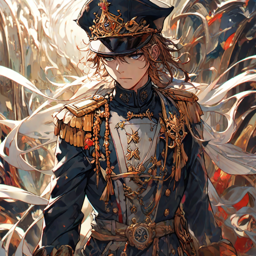

In [ ]:
from IPython.display import display
from PIL import Image

# 이미 존재하는 'image' 객체가 있다고 가정
small_image = image.copy()
small_image.thumbnail((256, 256))  # 256×256 이하로 축소
# 또는: small_image = image.resize((256, 256), resample=Image.Resampling.LANCZOS)

display(small_image)  # 축소된 이미지 표시


In [ ]:
prompt = "A woman, korean traditional uniform, stands with unwavering resolve. \
The uniform boasts intricate details, and her eyes black with determination. Strands of vibrant, windswept hair peek out from beneath the brim of her cap."

image = pipe(
    prompt=prompt,
    num_inference_steps=8,
    guidance_scale=0,
    eta=0.3,
    generator=torch.Generator(device=device).manual_seed(0),
).images[0]

  0%|          | 0/8 [00:00<?, ?it/s]

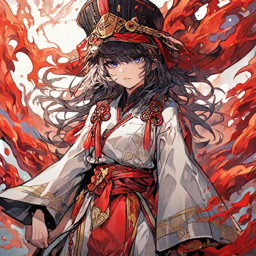

In [ ]:
from IPython.display import display
from PIL import Image

# 이미 존재하는 'image' 객체가 있다고 가정
small_image = image.copy()
small_image.thumbnail((256, 256))  # 256×256 이하로 축소
# 또는: small_image = image.resize((256, 256), resample=Image.Resampling.LANCZOS)

display(small_image)  # 축소된 이미지 표시


In [ ]:
# (1) 구글 Colab VM에 이미지 임시 저장
image.save("my_image.png")  # 파일 이름 + 확장자(예: .png)

# (2) Colab에서 내 로컬로 다운로드
from google.colab import files
files.download("my_image.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# prompt = "A futuristic city on Mars"
prompt = "Articles about blockchain Photos to post on Instagram"
negative_prompt = "complicacy, ugly, low quality"
seed = 42
num_inference_steps = 60
guidance_scale = 7.5

# 이미지 생성
generator = torch.Generator(device="cuda").manual_seed(seed)

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=num_inference_steps,
    guidance_scale=guidance_scale,
    generator=generator
).images[0]

image.save("output.png")


  0%|          | 0/60 [00:00<?, ?it/s]

In [ ]:
# negative_prompt : 이미지에 묘사되지 말아야 하는 텍스트

# seed : 시드에 따라 다양한 이미지 생성 (같은 프롬프트여도 시드가 다르면 이미지가 조금 달라짐)

# num_inference_steps : 추론 단계의 수, 일반적으로 사용하는 단계가 많을수록 품질이 좋아지지만 단계가 많을수록 생성 시간이 길어진다. (기본=50)

# guidance_scale : 프롬프트에 비슷한 정도, 보통 7~15를 씀, 너무 올리면 깨기도 함

# gfpgan : 얼굴 보정